In [1]:
#Kitabxanalar 
!pip install -q transformers datasets jiwer librosa soundfile tqdm accelerate
!pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 11.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 75.7 MB/s eta 0:00:00ta 0:00:01


In [2]:
#İmport-lar 
import os
import json
import warnings
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor
from datasets import load_dataset, Audio
from jiwer import wer, cer
warnings.filterwarnings('ignore')

In [3]:
#GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [4]:
#Output qovluğu 
OUTPUT_DIR = '/kaggle/working/results' if os.path.exists('/kaggle/working') else 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
#Konfiqurasiya 
DATASET_NAME  = 'google/fleurs'
LANGUAGE_CODE = 'az_az'
SPLIT         = 'test'
NUM_SAMPLES   = 100     
SAMPLE_RATE   = 16_000
BATCH_SIZE    = 8       

print(f'Dataset  : {DATASET_NAME} [{LANGUAGE_CODE}]')
print(f'Nümunə   : {NUM_SAMPLES}')
print(f'Batch    : {BATCH_SIZE}')

Dataset  : google/fleurs [az_az]
Nümunə   : 100
Batch    : 8


In [6]:
#Dataset yüklə 
print(f'Dataset yüklənir...')
ds = load_dataset(DATASET_NAME, LANGUAGE_CODE, split=SPLIT, streaming=True)
ds = ds.cast_column('audio', Audio(sampling_rate=SAMPLE_RATE))

sample = next(iter(ds))
print('Sütunlar:', list(sample.keys()))
print(f'Sampling rate : {sample["audio"]["sampling_rate"]} Hz')
print(f'Uzunluq       : {len(sample["audio"]["array"]) / SAMPLE_RATE:.2f}s')
print(f'Reference: "{sample["transcription"]}"')

Dataset yüklənir...


README.md:   0%|          | 0.00/386k [00:00<?, ?B/s]

Sütunlar: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Sampling rate : 16000 Hz
Uzunluq       : 16.20s
Reference: "elm adamları planetlərin xüsusilə də quyruqlu ulduzlar uzun zaman əvvəl yer planeti ilə toqquşduğu üçün yer planetinin necə yarandığını başa düşməyə çalışır"


In [7]:
samples = []
for item in tqdm(ds.take(NUM_SAMPLES), total=NUM_SAMPLES, desc='Yüklənir'):
    samples.append({
        'audio_array'  : item['audio']['array'].astype(np.float32),
        'sampling_rate': item['audio']['sampling_rate'],
        'reference'    : item['transcription'].strip(),
        'path'         : item.get('path', f'sample_{len(samples)}'),
    })

durations = [len(s['audio_array']) / SAMPLE_RATE for s in samples]
print(f'{len(samples)} nümunə yükləndi.')
print(f'Ortalama uzunluq : {np.mean(durations):.2f}s')
print(f'Min / Max        : {min(durations):.2f}s / {max(durations):.2f}s')

Yüklənir:   0%|          | 0/100 [00:00<?, ?it/s]

100 nümunə yükləndi.
Ortalama uzunluq : 12.64s
Min / Max        : 5.22s / 31.86s


In [8]:
#Model  
MODEL_ID = 'openai/whisper-large-v3'
print(f'Yüklənir: {MODEL_ID}  ({DEVICE}, {DTYPE})')

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    MODEL_ID,
    dtype=DTYPE,              
    low_cpu_mem_usage=True,
    use_safetensors=True,
).to(DEVICE)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model.eval()

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model yükləndi — {total_params:.0f}M parametr')

Yüklənir: openai/whisper-large-v3  (cuda, torch.float16)


config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.07k [00:00<?, ?B/s]

Model yükləndi — 1543M parametr


In [9]:
#Text normalizasiya funksiyası 
def normalize_az(text: str) -> str:
    """Azərbaycan mətni üçün normalizasiya: kiçik hərf, durğu işarəsi silmə."""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
#Batch inferens

print(f'Batch inferens başlayır (batch_size={BATCH_SIZE})...')
all_hypotheses = []

for i in tqdm(range(0, len(samples), BATCH_SIZE), desc='Batch inferens'):
    batch = samples[i : i + BATCH_SIZE]
    audio_arrays = [s['audio_array'] for s in batch]

    inputs = processor(
        audio_arrays,
        sampling_rate=SAMPLE_RATE,
        return_tensors='pt',
        padding=True,                
        return_attention_mask=True,  
    )

    input_features = inputs.input_features.to(DEVICE, dtype=DTYPE)
    attention_mask = inputs.attention_mask.to(DEVICE)  

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            attention_mask=attention_mask, 
            language='az',
            task='transcribe',
        )

    hyps = processor.batch_decode(predicted_ids, skip_special_tokens=True)
    all_hypotheses.extend([h.strip() for h in hyps])

for s, hyp in zip(samples, all_hypotheses):
    s['hypothesis'] = hyp

print(f'\nİnferens tamamlandı — {len(all_hypotheses)} hipotez.')
print('\nNümunə nəticələr:')
for i, s in enumerate(samples[:3]):
    print(f'  [{i+1}] REF : {s["reference"]}')
    print(f'       HYP : {s["hypothesis"]}')
    print()

Batch inferens başlayır (batch_size=8)...


Batch inferens:   0%|          | 0/13 [00:00<?, ?it/s]

A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.



İnferens tamamlandı — 100 hipotez.

Nümunə nəticələr:
  [1] REF : elm adamları planetlərin xüsusilə də quyruqlu ulduzlar uzun zaman əvvəl yer planeti ilə toqquşduğu üçün yer planetinin necə yarandığını başa düşməyə çalışır
       HYP : Elm adamları planetlərin xüsusilə də qoyruqlu ulduzlar uzun zaman əvvəl yer planeti ilə topuşduğu üçün yer planetinin necə yarandığını başa düşməyə çalışır.

  [2] REF : onun 20 yaşlarında olduğu bildirilir biber açıqlamasında bu faciəvi qəzanın birbaşa iştirakçısı olmasam da düşüncələrim və dualarım hadisə qurbanının ailəsinin yanındadır dedi
       HYP : Onun 20 yaşlarında olduğu bildirilir. Biber açıqlamasında, bu faziyəvi qazanın birbaşa iştirakçısı olmasam da, düşüncülərim və dualarım hadisə qurbanının ailəsinin yanındadır, dedi.

  [3] REF : pulcuq kimi dərisi və dırnaqları olan ayaqlara sahib bu quşlar yumurta qoya bilir və tirannozavr rekslər kimi iki arxa ayaqlarının üstündə gəzə bilirlər
       HYP : Pulcub kimi dərisi və dirnaqlaronla ayaqlar

In [11]:
# WER / CER  
wer_scores, cer_scores = [], []

for s in samples:
    ref = normalize_az(s['reference'])
    hyp = normalize_az(s['hypothesis'])
    s['ref_normalized'] = ref
    s['hyp_normalized'] = hyp

    if len(ref.strip()) == 0:
        s['wer'], s['cer'] = 1.0, 1.0
    else:
        s['wer'] = wer(ref, hyp)
        s['cer'] = cer(ref, hyp)

    wer_scores.append(s['wer'])
    cer_scores.append(s['cer'])

# Corpus-level (ağırlıqlı) metrikalar
all_refs   = [normalize_az(s['reference'])  for s in samples]
all_hyps_n = [normalize_az(s['hypothesis']) for s in samples]
global_wer = wer(all_refs, all_hyps_n)
global_cer = cer(all_refs, all_hyps_n)

print('=' * 52)
print('QLOBAL NƏTİCƏLƏR')
print('=' * 52)
print(f'  Corpus WER (ağırlıqlı) : {global_wer * 100:.2f}%')
print(f'  Corpus CER (ağırlıqlı) : {global_cer * 100:.2f}%')
print(f'  Ortalama WER           : {np.mean(wer_scores) * 100:.2f}%')
print(f'  Ortalama CER           : {np.mean(cer_scores) * 100:.2f}%')
print(f'  Mediana WER            : {np.median(wer_scores) * 100:.2f}%')
print(f'  Nümunə sayı            : {len(samples)}')
print('=' * 52)

QLOBAL NƏTİCƏLƏR
  Corpus WER (ağırlıqlı) : 19.86%
  Corpus CER (ağırlıqlı) : 4.76%
  Ortalama WER           : 19.25%
  Ortalama CER           : 4.49%
  Mediana WER            : 19.62%
  Nümunə sayı            : 100


In [12]:
# Ən yaxşı / ən pis 5 nümunə 
df = pd.DataFrame({
    'reference' : [s['reference']  for s in samples],
    'hypothesis': [s['hypothesis'] for s in samples],
    'wer'       : wer_scores,
    'cer'       : cer_scores,
})
df_sorted = df.sort_values('wer').reset_index(drop=True)

print('ƏN YAXŞI 5 NÜMUNƏ (aşağı WER):')
print('-' * 80)
for _, row in df_sorted.head(5).iterrows():
    print(f'  WER={row["wer"]*100:.1f}%  CER={row["cer"]*100:.1f}%')
    print(f'  REF : {row["reference"]}')
    print(f'  HYP : {row["hypothesis"]}')
    print()

print('ƏN PİS 5 NÜMUNƏ (yüksək WER):')
print('-' * 80)
for _, row in df_sorted.tail(5).iterrows():
    print(f'  WER={row["wer"]*100:.1f}%  CER={row["cer"]*100:.1f}%')
    print(f'  REF : {row["reference"]}')
    print(f'  HYP : {row["hypothesis"]}')
    print()

ƏN YAXŞI 5 NÜMUNƏ (aşağı WER):
--------------------------------------------------------------------------------
  WER=0.0%  CER=0.0%
  REF : maria adlanan qaranlıq qatların altında daha nazik dağlıq yerlərin altında isə daha qalın görünür
  HYP : Maria adlanan qaranlıq qatların altında daha nazik, dağlıq yerlərin altında isə daha qalın görünür.

  WER=0.0%  CER=0.0%
  REF : elektronlarından ayrılmış protonlar hidrogen ionları hesab olunur çünki hidrogen atomları bir proton və bir elektrondan ibarətdir
  HYP : Elektronlarından ayrılmış protonlar hidrogen ionları hesab olunur. Çünki hidrogen atomları bir proton və bir elektrondan ibarətdir.

  WER=0.0%  CER=0.0%
  REF : bu tapıntı həm də quş lələklərinin təkamülü haqqında təsəvvür yaradır
  HYP : Bu tapıntı həm də quş lələklərinin təkamülü haqqında təsəvvür yaradır.

  WER=0.0%  CER=0.0%
  REF : alimlər bu qənaətə gəldilər ki qaranlıq materiyanın digərinə təsiri adi materiyanın eyni formada göstərdiyi təsir kimidir
  HYP : Alimlər bu qən

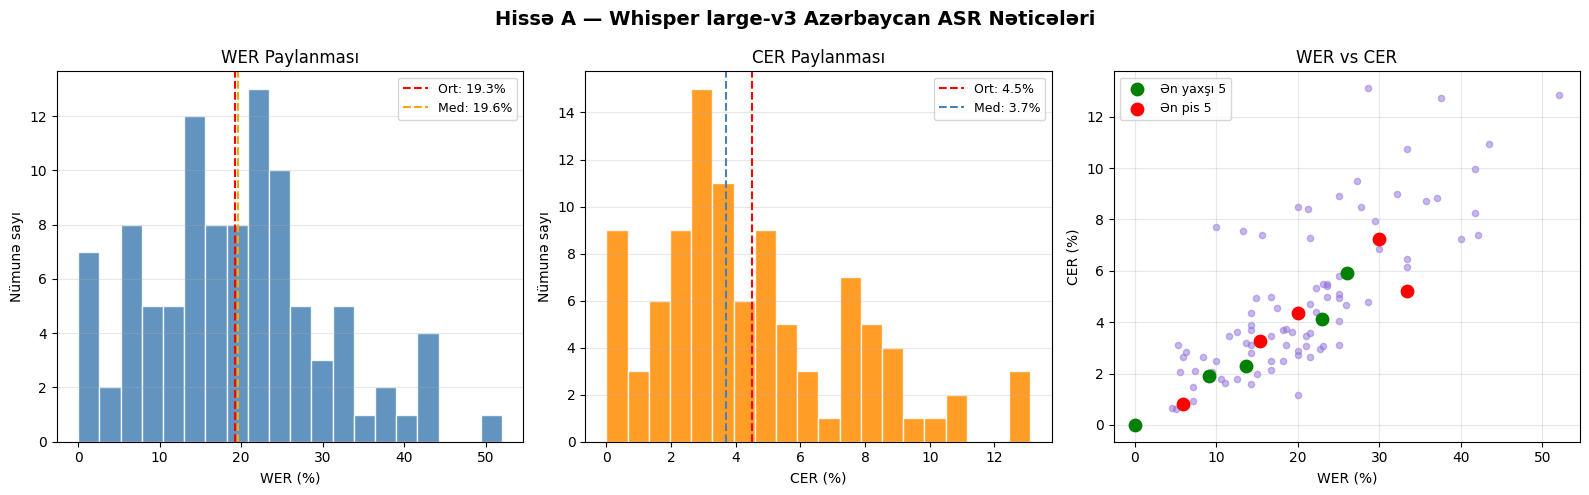

In [13]:
# Vizualizasiyalar 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hissə A — Whisper large-v3 Azərbaycan ASR Nəticələri',
             fontsize=14, fontweight='bold')

wer_pct = [w * 100 for w in wer_scores]
cer_pct = [c * 100 for c in cer_scores]

# 1) WER histogram
ax1 = axes[0]
ax1.hist(wer_pct, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(np.mean(wer_pct),   color='red',    linestyle='--', lw=1.5,
            label=f'Ort: {np.mean(wer_pct):.1f}%')
ax1.axvline(np.median(wer_pct), color='orange', linestyle='--', lw=1.5,
            label=f'Med: {np.median(wer_pct):.1f}%')
ax1.set_xlabel('WER (%)'); ax1.set_ylabel('Nümunə sayı')
ax1.set_title('WER Paylanması')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# 2) CER histogram
ax2 = axes[1]
ax2.hist(cer_pct, bins=20, color='darkorange', edgecolor='white', alpha=0.85)
ax2.axvline(np.mean(cer_pct),   color='red',       linestyle='--', lw=1.5,
            label=f'Ort: {np.mean(cer_pct):.1f}%')
ax2.axvline(np.median(cer_pct), color='steelblue', linestyle='--', lw=1.5,
            label=f'Med: {np.median(cer_pct):.1f}%')
ax2.set_xlabel('CER (%)'); ax2.set_ylabel('Nümunə sayı')
ax2.set_title('CER Paylanması')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# 3) WER vs CER scatter
ax3 = axes[2]
ax3.scatter(wer_pct, cer_pct, alpha=0.5, s=20, color='mediumpurple')
best_idx  = df_sorted.head(5).index.tolist()
worst_idx = df_sorted.tail(5).index.tolist()
ax3.scatter([wer_pct[i] for i in best_idx],  [cer_pct[i] for i in best_idx],
            color='green', s=80, zorder=5, label='Ən yaxşı 5')
ax3.scatter([wer_pct[i] for i in worst_idx], [cer_pct[i] for i in worst_idx],
            color='red',   s=80, zorder=5, label='Ən pis 5')
ax3.set_xlabel('WER (%)'); ax3.set_ylabel('CER (%)')
ax3.set_title('WER vs CER')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
out_path = f'{OUTPUT_DIR}/part_a_metrics.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

In [14]:
#Nəticələr
df_full = pd.DataFrame({
    'id'        : range(1, len(samples) + 1),
    'reference' : [s['reference']  for s in samples],
    'hypothesis': [s['hypothesis'] for s in samples],
    'wer_pct'   : [round(w * 100, 2) for w in wer_scores],
    'cer_pct'   : [round(c * 100, 2) for c in cer_scores],
})
df_full.to_csv(f'{OUTPUT_DIR}/part_a_results.csv', index=False, encoding='utf-8-sig')

summary = pd.DataFrame({
    'Metrika': ['Corpus WER', 'Corpus CER', 'Ortalama WER',
                'Ortalama CER', 'Mediana WER', 'Nümunə sayı'],
    'Nəticə': [
        f'{global_wer * 100:.2f}%',
        f'{global_cer * 100:.2f}%',
        f'{np.mean(wer_scores) * 100:.2f}%',
        f'{np.mean(cer_scores) * 100:.2f}%',
        f'{np.median(wer_scores) * 100:.2f}%',
        str(len(samples))
    ]
})
summary.to_csv(f'{OUTPUT_DIR}/part_a_summary.csv', index=False, encoding='utf-8-sig')
print('XÜLASƏ CƏDVƏLİ:')
print(summary.to_string(index=False))

model_info = {
    'model_id'   : MODEL_ID,
    'dataset'    : f'{DATASET_NAME}/{LANGUAGE_CODE}',
    'language'   : 'azerbaijani',
    'task'       : 'transcribe',
    'device'     : DEVICE,
    'dtype'      : str(DTYPE),
    'num_samples': len(samples),
    'batch_size' : BATCH_SIZE,
    'corpus_wer' : round(global_wer * 100, 2),
    'corpus_cer' : round(global_cer * 100, 2),
    'mean_wer'   : round(np.mean(wer_scores) * 100, 2),
    'mean_cer'   : round(np.mean(cer_scores) * 100, 2),
}
with open(f'{OUTPUT_DIR}/model_info.json', 'w', encoding='utf-8') as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

print(f'\nHissə A tamamlandı')
print(f'   Corpus WER = {global_wer * 100:.2f}%')
print(f'   Corpus CER = {global_cer * 100:.2f}%')
print(f'   Fayllar    : {OUTPUT_DIR}/')

XÜLASƏ CƏDVƏLİ:
     Metrika Nəticə
  Corpus WER 19.86%
  Corpus CER  4.76%
Ortalama WER 19.25%
Ortalama CER  4.49%
 Mediana WER 19.62%
 Nümunə sayı    100

Hissə A tamamlandı
   Corpus WER = 19.86%
   Corpus CER = 4.76%
   Fayllar    : /kaggle/working/results/
